<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologias Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Linea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibague-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingenieria</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingenieria de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab -- 03 Dataset Split</div>

# 03 -- Dataset Split

Divide las imagenes aceptadas en `data/processed/` en tres conjuntos:

| Conjunto | Uso | Proporcion |
|----------|-----|-----------|
| **train** | Ajuste de pesos del modelo | 75% |
| **val**   | Monitoreo durante entrenamiento | 15% |
| **test**  | Evaluacion final (nunca vista en entrenamiento) | 10% |

### Garantias de `split_dataset`
- Reproducible: misma semilla (`seed=42`) produce siempre el mismo reparto.
- Sin leakage: cada imagen aparece en exactamente un split.
- Balanceado por clase: el reparto respeta las proporciones dentro de cada especie.
- Clases pequeñas (n >= 3): al menos 1 imagen en val y test por clase.


## 1. Setup

In [1]:
import sys
import shutil
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import yaml

# ── Logging visible en el notebook ──────────────────────────────
logging.basicConfig(
    format="[%(levelname)s] %(message)s",
    level=logging.INFO,
)

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.split import split_dataset, DEFAULT_RATIOS

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

ratios = tuple(config.get("split_ratio", list(DEFAULT_RATIOS)))

# ── Resumen de configuracion ─────────────────────────────────────
SEP = "-" * 44
print(SEP)
print("  CONFIGURACION DEL SPLIT")
print(SEP)
print(f"  Proyecto     : {PROJECT_ROOT.name}")
print(f"  Config       : configs/dataset.yaml")
print(f"  Ratios       : train={ratios[0]}  val={ratios[1]}  test={ratios[2]}")
print(f"  Semilla      : 42  (determinista)")
print(SEP)


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


--------------------------------------------
  CONFIGURACION DEL SPLIT
--------------------------------------------
  Proyecto     : aves
  Config       : configs/dataset.yaml
  Ratios       : train=0.75  val=0.15  test=0.1
  Semilla      : 42  (determinista)
--------------------------------------------


## 2. Test sintetico -- verificacion de leakage

Antes de tocar el dataset real creamos un dataset ficticio minimo para
confirmar que la funcion reparte sin solapamiento entre splits.


In [2]:
# Crear dataset sintetico temporal
tmp_root   = PROJECT_ROOT / "data" / "_tmp_split_test"
tmp_input  = tmp_root / "accepted"
tmp_output = tmp_root / "split"

if tmp_root.exists():
    shutil.rmtree(tmp_root)

SYNTHETIC = {"class_a": 12, "class_b": 5, "class_c": 3}
for cls, n in SYNTHETIC.items():
    (tmp_input / cls).mkdir(parents=True, exist_ok=True)
    for i in range(n):
        (tmp_input / cls / f"{cls}_{i:03d}.jpg").write_bytes(b"x")

summary_tmp = split_dataset(
    input_dir  = tmp_input,
    output_dir = tmp_output,
    ratios     = ratios,
    seed       = 42,
)

# ── Verificar leakage ────────────────────────────────────────────
print("  TEST SINTETICO -- VERIFICACION DE LEAKAGE")
print(SEP)
print(f"  {'Clase':<12} {'Total':>6}  {'Train':>6}  {'Val':>5}  {'Test':>5}  {'Leakage':>8}")
print(f"  {'-'*12} {'-'*6}  {'-'*6}  {'-'*5}  {'-'*5}  {'-'*8}")

all_ok = True
for cls, counts in sorted(summary_tmp["per_class"].items()):
    split_sets = [
        {p.name for p in (tmp_output / s / cls).glob("*") if p.is_file()}
        for s in ("train", "val", "test")
    ]
    n_total = sum(counts.values())
    leaked  = any(
        split_sets[i] & split_sets[j]
        for i in range(3) for j in range(i + 1, 3)
    )
    if leaked:
        all_ok = False
    status = "OK" if not leaked else "LEAK!"
    print(f"  {cls:<12} {n_total:>6}  {counts['train']:>6}  {counts['val']:>5}  {counts['test']:>5}  {status:>8}")

print(SEP)
print(f"  Resultado: {'SIN LEAKAGE -- todo correcto' if all_ok else 'LEAKAGE DETECTADO'}")
print(SEP)


[INFO] Class 'class_a' (12 total): train=10 val=1 test=1
[INFO] Class 'class_b' (5 total): train=3 val=1 test=1
[INFO] Class 'class_c' (3 total): train=1 val=1 test=1
[INFO] Split complete: classes=3  total=20  train=14  val=3  test=3


  TEST SINTETICO -- VERIFICACION DE LEAKAGE
--------------------------------------------
  Clase         Total   Train    Val   Test   Leakage
  ------------ ------  ------  -----  -----  --------
  class_a          12      10      1      1        OK
  class_b           5       3      1      1        OK
  class_c           3       1      1      1        OK
--------------------------------------------
  Resultado: SIN LEAKAGE -- todo correcto
--------------------------------------------


## 3. Split del dataset real

Lee las imagenes aceptadas desde `data/processed/` y las distribuye en
`data/split/train`, `data/split/val` y `data/split/test`.

> **Atencion:** esta celda borra y recrea `data/split/` si ya existe.


In [3]:
accepted_dir = PROJECT_ROOT / config.get("processed_data_path", "data/processed")
split_dir    = PROJECT_ROOT / "data" / "split"

print(SEP)
print("  SPLIT DEL DATASET REAL")
print(SEP)
print(f"  Entrada : {accepted_dir.relative_to(PROJECT_ROOT)}")
print(f"  Salida  : {split_dir.relative_to(PROJECT_ROOT)}")
print(f"  Ratios  : train={ratios[0]}  val={ratios[1]}  test={ratios[2]}")
print(SEP)

if not accepted_dir.exists():
    print("  [!] data/processed/ no existe. Ejecuta 02_preprocessing primero.")
    summary = None
else:
    summary = split_dataset(
        input_dir  = accepted_dir,
        output_dir = split_dir,
        ratios     = ratios,
        seed       = 42,
        use_symlinks = False,
    )
    t = summary["totals"]
    print()
    print(f"  Clases procesadas : {summary['num_classes']}")
    print(f"  Imagenes totales  : {summary['num_images']}")
    print()
    print(f"  {'Split':<8}  {'Imagenes':>9}  {'%':>6}")
    print(f"  {'-'*8}  {'-'*9}  {'-'*6}")
    for s in ("train", "val", "test"):
        pct = t[s] / summary['num_images'] * 100 if summary['num_images'] else 0
        print(f"  {s:<8}  {t[s]:>9}  {pct:>5.1f}%")
    print(SEP)


--------------------------------------------
  SPLIT DEL DATASET REAL
--------------------------------------------
  Entrada : data/processed
  Salida  : data/split
  Ratios  : train=0.75  val=0.15  test=0.1
--------------------------------------------


[INFO] Class 'ardea-alba' (64 total): train=49 val=9 test=6
[INFO] Class 'atlapetes-latinuchus' (97 total): train=73 val=15 test=9
[INFO] Class 'butorides-striata' (70 total): train=53 val=10 test=7
[INFO] Class 'chlorochrysa-nitidissima' (123 total): train=93 val=18 test=12
[INFO] Class 'colibri-coruscans' (62 total): train=47 val=9 test=6
[INFO] Class 'common-gallinule' (51 total): train=39 val=7 test=5
[INFO] Class 'metallura-tyrianthina' (78 total): train=59 val=12 test=7
[INFO] Class 'momotus-aequatorialis' (132 total): train=100 val=19 test=13
[INFO] Class 'phimosus-infuscatus' (111 total): train=84 val=16 test=11
[INFO] Class 'piaya-cayana' (40 total): train=30 val=6 test=4
[INFO] Class 'pitangus-sulphuratus' (101 total): train=76 val=15 test=10
[INFO] Class 'ramphastos-ambiguus' (57 total): train=43 val=9 test=5
[INFO] Class 'sicalis-flaveola' (118 total): train=89 val=18 test=11
[INFO] Class 'thraupis-episcopus' (111 total): train=84 val=16 test=11
[INFO] Class 'turdus-fuscate


  Clases procesadas : 16
  Imagenes totales  : 1383

  Split      Imagenes       %
  --------  ---------  ------
  train          1046   75.6%
  val             204   14.8%
  test            133    9.6%
--------------------------------------------


## 4. Distribucion por clase

In [4]:
if summary:
    pc = summary["per_class"]
    total_imgs = summary["num_images"]

    print(f"  {'Especie':<35}  {'Total':>6}  {'Train':>6}  {'Val':>5}  {'Test':>5}  {'Train%':>7}")
    print(f"  {'-'*35}  {'-'*6}  {'-'*6}  {'-'*5}  {'-'*5}  {'-'*7}")

    for cls in sorted(pc):
        c     = pc[cls]
        total = sum(c.values())
        tr_pct = c['train'] / total * 100 if total else 0
        print(f"  {cls:<35}  {total:>6}  {c['train']:>6}  {c['val']:>5}  {c['test']:>5}  {tr_pct:>6.1f}%")

    print(f"  {'='*35}  {'='*6}  {'='*6}  {'='*5}  {'='*5}  {'='*7}")
    t = summary['totals']
    tr_pct_total = t['train'] / total_imgs * 100
    print(f"  {'TOTAL':<35}  {total_imgs:>6}  {t['train']:>6}  {t['val']:>5}  {t['test']:>5}  {tr_pct_total:>6.1f}%")


  Especie                               Total   Train    Val   Test   Train%
  -----------------------------------  ------  ------  -----  -----  -------
  ardea-alba                               64      49      9      6    76.6%
  atlapetes-latinuchus                     97      73     15      9    75.3%
  butorides-striata                        70      53     10      7    75.7%
  chlorochrysa-nitidissima                123      93     18     12    75.6%
  colibri-coruscans                        62      47      9      6    75.8%
  common-gallinule                         51      39      7      5    76.5%
  metallura-tyrianthina                    78      59     12      7    75.6%
  momotus-aequatorialis                   132     100     19     13    75.8%
  phimosus-infuscatus                     111      84     16     11    75.7%
  piaya-cayana                             40      30      6      4    75.0%
  pitangus-sulphuratus                    101      76     15     10    75.2%

## 5. Visualizacion

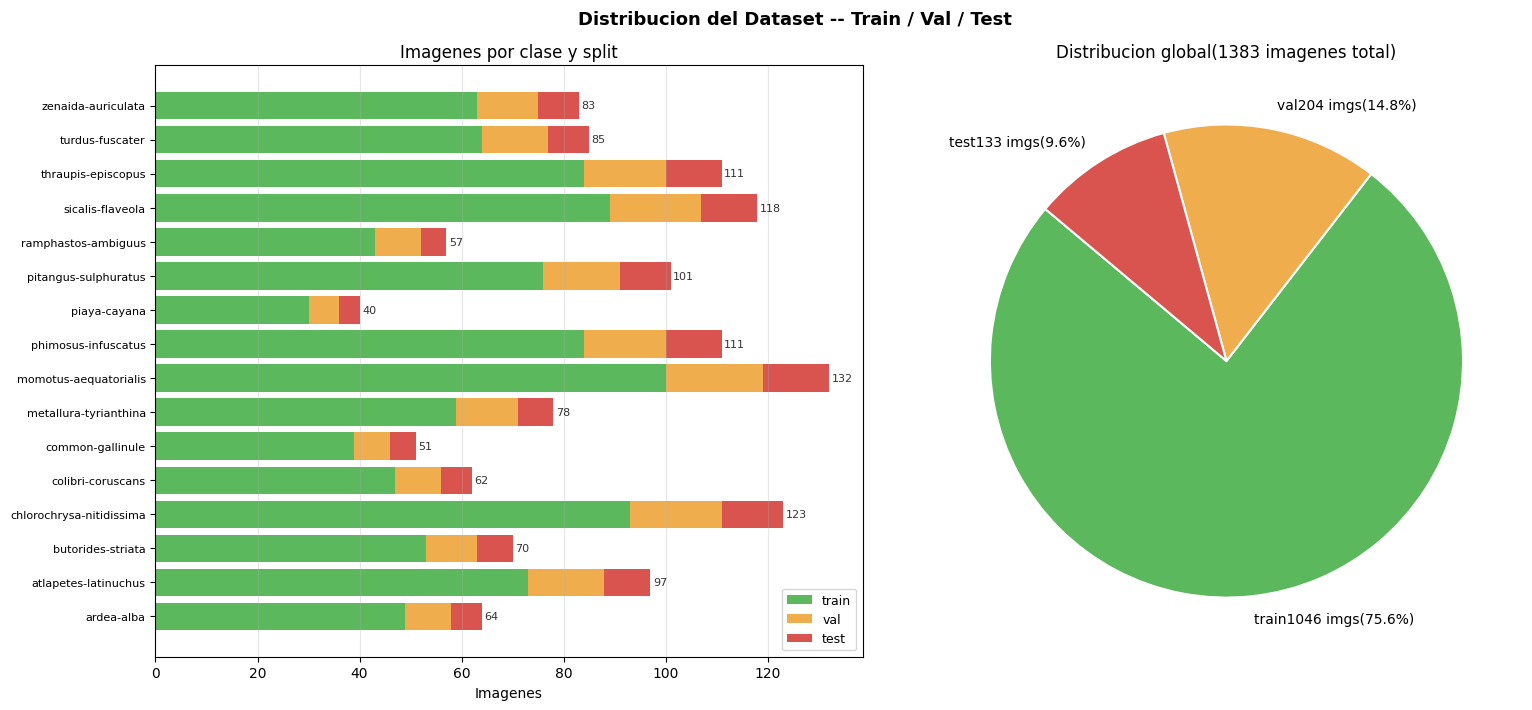

Grafica guardada en logs/03_split_distribution.png


In [6]:
if summary:
    pc      = summary["per_class"]
    classes = sorted(pc.keys())

    train_vals = [pc[c]["train"] for c in classes]
    val_vals   = [pc[c]["val"]   for c in classes]
    test_vals  = [pc[c]["test"]  for c in classes]
    totals     = [sum(pc[c].values()) for c in classes]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(classes) * 0.45)))
    fig.suptitle("Distribucion del Dataset -- Train / Val / Test",
                 fontsize=13, fontweight="bold")

    # ── Panel izquierdo: barras apiladas por clase ───────────────
    ax = axes[0]
    x  = range(len(classes))
    b1 = ax.barh(list(x), train_vals, color="#5cb85c", label="train")
    b2 = ax.barh(list(x), val_vals,   color="#f0ad4e", label="val",
                 left=train_vals)
    b3 = ax.barh(list(x), test_vals,  color="#d9534f", label="test",
                 left=[tr + v for tr, v in zip(train_vals, val_vals)])

    ax.set_yticks(list(x))
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel("Imagenes")
    ax.set_title("Imagenes por clase y split")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.3, axis="x")

    # Etiqueta con total al final de la barra
    for i, total in enumerate(totals):
        ax.text(total + 0.5, i, str(total), va="center", fontsize=8, color="#333")

    # ── Panel derecho: torta global ──────────────────────────────
    ax2 = axes[1]
    t   = summary["totals"]
    sizes  = [t["train"], t["val"], t["test"]]
    colors = ["#5cb85c", "#f0ad4e", "#d9534f"]
    labels_pie = [
        f"train{t['train']} imgs({t['train']/summary['num_images']*100:.1f}%)",
        f"val{t['val']} imgs({t['val']/summary['num_images']*100:.1f}%)",
        f"test{t['test']} imgs({t['test']/summary['num_images']*100:.1f}%)",
    ]
    ax2.pie(sizes, labels=labels_pie, colors=colors, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    ax2.set_title(f"Distribucion global({summary['num_images']} imagenes total)")

    plt.tight_layout()
    log_dir = PROJECT_ROOT / "logs"
    log_dir.mkdir(exist_ok=True)
    plt.savefig(log_dir / "03_split_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grafica guardada en logs/03_split_distribution.png")


## 6. Verificacion de leakage en el split real

In [7]:
if summary:
    print(f"  {'Especie':<35}  {'Leakage':>8}  {'Train':>6}  {'Val':>5}  {'Test':>5}")
    print(f"  {'-'*35}  {'-'*8}  {'-'*6}  {'-'*5}  {'-'*5}")

    all_clean = True
    for cls in sorted(summary["per_class"]):
        sets = []
        for s in ("train", "val", "test"):
            d = split_dir / s / cls
            names = {p.name for p in d.glob("*") if p.is_file()} if d.exists() else set()
            sets.append(names)

        leaked = any(sets[i] & sets[j] for i in range(3) for j in range(i+1, 3))
        if leaked:
            all_clean = False

        c      = summary["per_class"][cls]
        status = "[OK]" if not leaked else "[LEAK!]"
        print(f"  {cls:<35}  {status:>8}  {c['train']:>6}  {c['val']:>5}  {c['test']:>5}")

    print(f"  {'='*62}")
    result_str = "SIN LEAKAGE -- dataset listo para entrenamiento" if all_clean else "LEAKAGE DETECTADO -- revisar split"
    print(f"  Resultado: {result_str}")


  Especie                               Leakage   Train    Val   Test
  -----------------------------------  --------  ------  -----  -----
  ardea-alba                               [OK]      49      9      6
  atlapetes-latinuchus                     [OK]      73     15      9
  butorides-striata                        [OK]      53     10      7
  chlorochrysa-nitidissima                 [OK]      93     18     12
  colibri-coruscans                        [OK]      47      9      6
  common-gallinule                         [OK]      39      7      5
  metallura-tyrianthina                    [OK]      59     12      7
  momotus-aequatorialis                    [OK]     100     19     13
  phimosus-infuscatus                      [OK]      84     16     11
  piaya-cayana                             [OK]      30      6      4
  pitangus-sulphuratus                     [OK]      76     15     10
  ramphastos-ambiguus                      [OK]      43      9      5
  sicalis-flaveola  

## 7. Limpieza y siguiente paso

In [10]:
# Eliminar archivos sinteticos del test de la seccion 2
if tmp_root.exists():
    shutil.rmtree(tmp_root)
    print(f"Archivos sinteticos eliminados: {tmp_root.relative_to(PROJECT_ROOT)}")

if summary:
    print()
    print(SEP)
    print("  RESUMEN FINAL")
    print(SEP)
    print(f"  Clases  : {summary['num_classes']}")
    print(f"  Total   : {summary['num_images']} imagenes")
    t = summary['totals']
    for s in ('train', 'val', 'test'):
        pct = t[s] / summary['num_images'] * 100
        print(f"  {s:<7} : {t[s]:>5} ({pct:.1f}%)")
    print(SEP)
    print()
    print("Siguiente paso --> notebooks/04_training.ipynb")
    print(f" Usar: data/split/  como DATASET_ROOT del entrenamiento")



--------------------------------------------
  RESUMEN FINAL
--------------------------------------------
  Clases  : 16
  Total   : 1383 imagenes
  train   :  1046 (75.6%)
  val     :   204 (14.8%)
  test    :   133 (9.6%)
--------------------------------------------

Siguiente paso --> notebooks/04_training.ipynb
 Usar: data/split/  como DATASET_ROOT del entrenamiento
